## Analyze inter-cluster angles

In [128]:
from pathlib import Path
from tqdm import tqdm
from itertools import product
import matplotlib.pyplot as plt
import seaborn as sns
import seaborn.objects as so
import pandas as pd
import numpy as np
import concurrent.futures
import sys
import os

# 
project_workdir = Path("/home/woodydrylab/DiskArray/b05b01002/project_umap_re/")
path_param_sets = project_workdir / "outputs/UMAP/param_table.csv"
path_seed_list = project_workdir / "outputs/UMAP/seeds.txt"

# class holding file paths
class PathFactory:
    def __init__(self, base):
        self._templates = {
            "ica": base / "outputs/InterClusterAngle/{sample}/seed{seed}.csv",
            "cluster": base / "outputs/Seurat/{sample}/clusters.csv",
            "pca": base / "outputs/Seurat/{sample}/pca.csv",
            "embeddings": base / "outputs/UMAP/{sample}/seed{seed}/param_set{param_set}.csv",
            "ica_aligned": base / (
                "outputs/InterClusterAngle/{sample}/per_{n}_embeddings/param_set{param_set}_median.csv"
            ),
            "aligned_rmsd": base / (
                "outputs/AlignEmbeddings/procrustes_alignment/{sample}/"
                "per_{n}_embeddings/param_set{param_set}/batch_{batch}/mean_rmsd.csv"
            ),
            "outdir": base / "notebooks/inter-cluster-angle/temp/results_20260225/"
        }

    @staticmethod
    def path_maker(template, **kwargs):
        template = str(template)
        for k, v in kwargs.items():
            template = template.replace("{"+ k +"}", str(v))
        return Path(template)

    def __getattr__(self, name):
        template = self._templates[name]
        return lambda **kwargs: PathFactory.path_maker(template, **kwargs)

paths = PathFactory(project_workdir)

### Get or set sample names (from command line or manually define)

In [3]:
if not 'ipykernel' in sys.modules:
    samples = sys.argv[1:]
else:    
    # samples = ["ath", "gar", "lch", "osa", "ptr", "tma", "zma"]
    samples = ["ath", "gar", "lch", "osa", "ptr", "tma", "zma"]

print("[Python] Running samples =", samples)

[Python] Running samples = ['ath', 'gar', 'lch', 'osa', 'ptr', 'tma', 'zma']


### Create output directory

In [89]:
os.makedirs(paths.outdir(), exist_ok=True)
print(paths.outdir())

/home/woodydrylab/DiskArray/b05b01002/project_umap_re/notebooks/inter-cluster-angle/temp/results_20260225


### Read data

#### 1. UMAP seeds

In [4]:
seeds = [l.strip() for l in open(path_seed_list, "r")]
len(seeds)

1000

#### 2. Parameter sets

In [5]:
param_sets = pd.read_csv(path_param_sets, index_col = 0)
param_sets.describe()

,n_neighbors,min_dist,n_epochs
count,360.000000,360.000000,360.000000
mean,78.000000,0.448333,375.000000
std,68.035711,0.357354,238.816721
min,10.000000,0.000000,100.000000
25%,30.000000,0.100000,175.000000
50%,50.000000,0.400000,350.000000
75%,100.000000,0.800000,550.000000
max,200.000000,0.990000,700.000000


#### 3. Cluster dfs

In [6]:
cluster_dfs = {
    sample: pd.read_csv(
        paths.cluster(sample=sample),
        index_col=0,
        dtype=str,
        header=0,
        names=["cluster"] # overwrite existing headers
    ) for sample in samples
}
cluster_dfs[samples[0]]

,cluster
AAACCCAAGAGCCATG,9
AAACCCAAGCTGAAGC,7
AAACCCAAGGAAGAAC,0
AAACCCAAGGGAGAAT,6
AAACCCAAGGGTGAGG,4
...,...
TTTGTTGTCACCGGGT,10
TTTGTTGTCACCTGGG,7
TTTGTTGTCCTGGTCT,5
TTTGTTGTCGCGTGAC,1


#### 4. Inter-cluster angle

In [7]:
def stat_inter_cluster_angles(df: pd.DataFrame) -> pd.DataFrame:
    """
    Docstring explaining the function's purpose.

    Args:
        parameter_name (type): Description of the argument.
        df (pd.DataFrame): 
            A dataframe with columns:
            param_set, seed, vertex, cluster_a, cluster_b, cos_similarity

    Returns:
        pd.DataFrame:
            A dataframe with columns:
            param_set, vertex, cluster_a, cluster_b, degree_max, degree_min, seed_max, seed_min
    """
    # convert consine
    df["degree"] = df["cos_similarity"].apply(lambda x: np.degrees(np.arccos(x)))
    g_df = df.groupby(["param_set", "vertex", "cluster_a", "cluster_b"])

    # find max & min degree and the corresponding seeds; the iqr and sd of the degree
    ica_max_min = (
        g_df.agg(
            max_degree=("degree", "max"),
            min_degree=("degree", "min"),
            iqr_degree=("degree", iqr),
            degree_sd=("degree", "std")
        )
        .assign(
            max_degree_seed=df.loc[
                g_df["degree"].idxmax().values, "seed"
            ].values,
            min_degree_seed=df.loc[
                g_df["degree"].idxmin().values, "seed"
            ].values,
        )
    )

    # calculate differece between max and min degree
    ica_max_min["delta_max_min"] = ica_max_min.apply(lambda x: abs(x["max_degree"] - x["min_degree"]), axis=1)
    
    # 
    ica_max_min["sample"] = sample
    return ica_max_min

In [11]:
ica_dfs = {}
for sample in samples:
    with concurrent.futures.ProcessPoolExecutor(max_workers=48) as executor:
        print(f"sample={sample}", end="")
        # submit jobs to pool
        futures = [
            executor.submit(pd.read_csv, paths.ica(sample=sample, seed=seed)) 
            for seed in seeds
        ]

        # store concurrent results to list
        df_list = []
        for fut in tqdm(
            concurrent.futures.as_completed(futures),
            total=len(futures)
        ):
            df_temp = fut.result()
            mask1 = df_temp["vertex"] < 8
            mask2 = df_temp["cluster_a"] < 8
            mask3 = df_temp["cluster_b"] < 8
            df_temp = df_temp[mask1 & mask2 & mask3]
            df_list.append(df_temp)

        # concat dataframe and map to dict for named access
        print("Concat...")
        ica_dfs[sample] = pd.concat(df_list, ignore_index=True)

        del df_list

sample=ath

100%|██████████████████████████████████████████████████| 1000/1000 [01:19<00:00, 12.61it/s]


Concat...
sample=gar

100%|██████████████████████████████████████████████████████████| 1000/1000 [02:00<00:00,  8.29it/s]


Concat...
sample=lch

...

Concat...
sample=tma

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [02:31<00:00,  6.59it/s]


Concat...
sample=zma

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:18<00:00, 54.97it/s]


Concat...


_**Use only results of the first 8 clusters**_

In [12]:
for sample, ica_df in ica_dfs.items():
    print(sample, ica_dfs[sample].shape)

ath (60480000, 6)
gar (60480000, 6)
lch (60480000, 6)
osa (60480000, 6)
ptr (60480000, 6)
tma (60480000, 6)
zma (60480000, 6)


_**Convert cosine similarity to degree**_

In [13]:
for sample, ica_df in ica_dfs.items():
    ica_df["radian"] = ica_df["cos_similarity"].apply(np.arccos)
    ica_df["degree"] = ica_df["radian"].apply(np.degrees)
    ica_df.drop(columns=["cos_similarity", "radian"])

### Stats per parameter sets per cluster combinations for the followings:  
- SD
- max/min degree (and corresponding seeds)
- max degree difference

In [16]:
stat_df = pd.DataFrame()
for sample, ica_df in ica_dfs.items():
    g_df = ica_df.groupby(["param_set", "vertex", "cluster_a", "cluster_b"])
    foo = (
        g_df.agg(
            max_degree=("degree", "max"),
            min_degree=("degree", "min"),
            degree_sd=("degree", "std")
        )
        .assign(
            max_degree_seed=ica_df.loc[
                g_df["degree"].idxmax().values, "seed"
            ].values,
            min_degree_seed=ica_df.loc[
                g_df["degree"].idxmin().values, "seed"
            ].values,
        )
    )
    foo["delta_max_min"] = foo.apply(lambda x: abs(x["max_degree"] - x["min_degree"]), axis=1)
    foo = pd.merge(foo, param_sets, left_index=True, right_index=True, how="left")
    foo["sample"] = sample
    stat_df = pd.concat([stat_df, foo])
    stat_df = stat_df.reset_index()

In [33]:
stat_df.head()

,param_set,vertex,cluster_a,cluster_b,max_degree,min_degree,degree_sd,max_degree_seed,min_degree_seed,delta_max_min,n_neighbors,min_dist,metric,n_epochs,sample
0,0,0,1,2,36.232564,0.069192,10.225038,73464,10851,36.163372,10,0.0,euclidean,100,ath
1,0,0,1,3,27.942882,0.003392,6.115227,66207,83385,27.939490,10,0.0,euclidean,100,ath
2,0,0,1,4,29.958105,0.012542,5.378503,42325,53279,29.945562,10,0.0,euclidean,100,ath
3,0,0,1,5,46.401134,0.042610,10.155650,30028,87236,46.358523,10,0.0,euclidean,100,ath
4,0,0,1,6,61.184231,2.635450,10.090987,13617,52600,58.548780,10,0.0,euclidean,100,ath


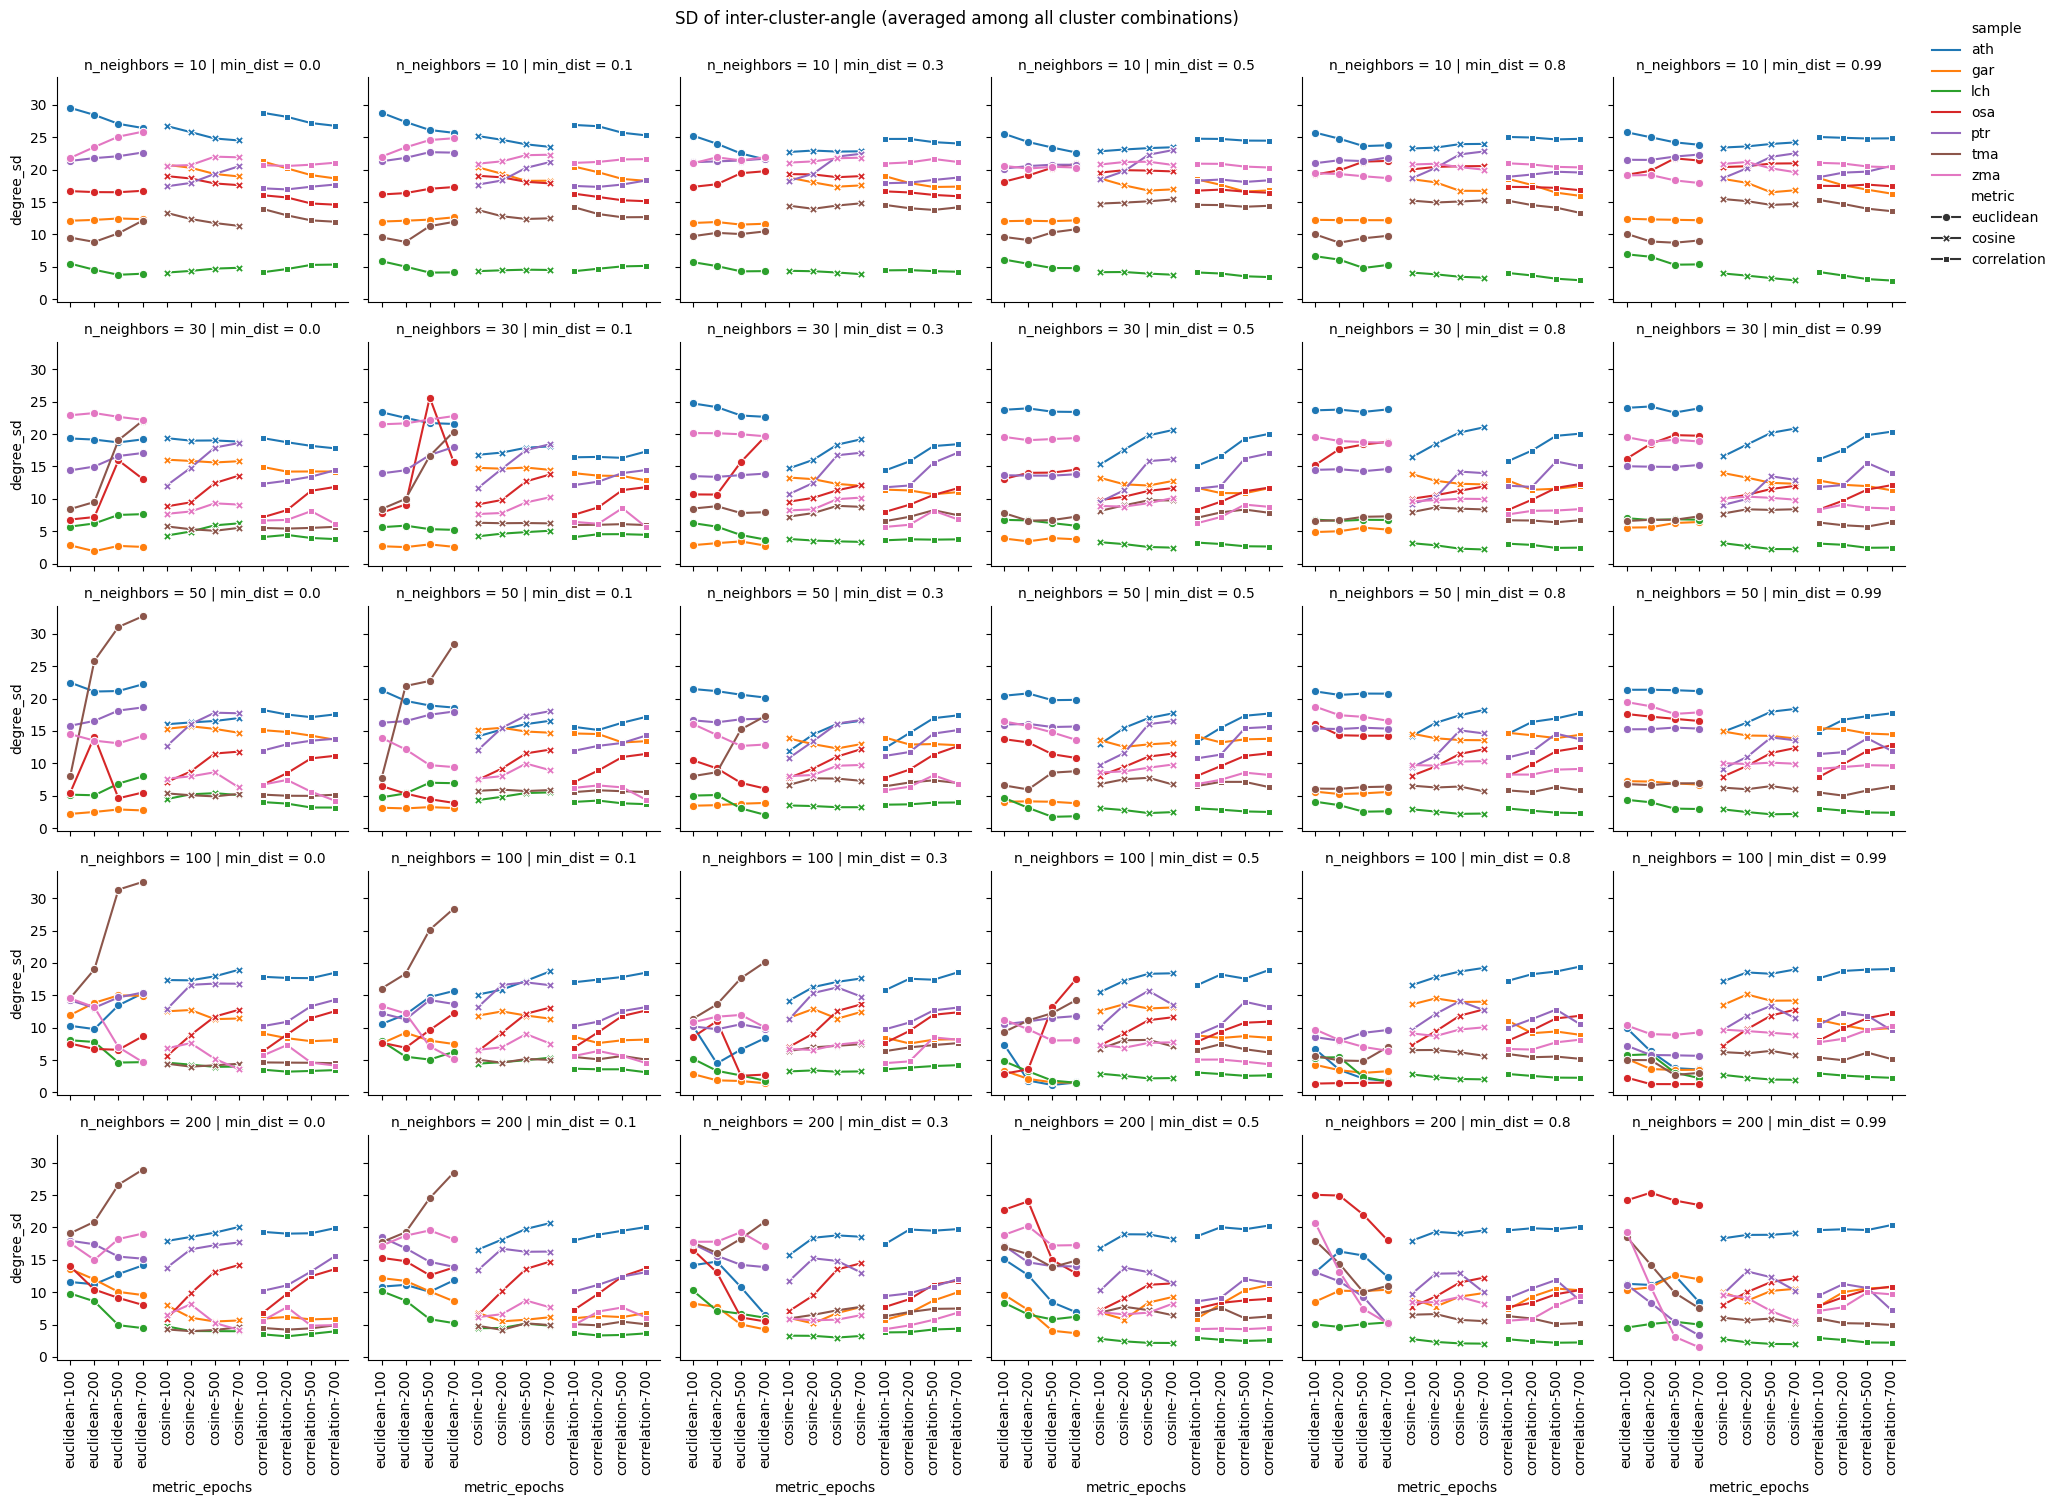

In [112]:
# data = stat_df.groupby(["n_neighbors", "min_dist", "metric", "n_epochs", "sample"]).mean().reset_index()
data = stat_df.copy()
data["metric_epochs"] = data.apply(lambda x: f"{x.metric}-{x.n_epochs}", axis=1)
g = sns.FacetGrid(
    data,
    row="n_neighbors",
    col="min_dist",
)
g.map_dataframe(
    sns.lineplot,
    x="metric_epochs",
    y="degree_sd",
    hue="sample",
    style="metric",
    palette="tab10",
    err_style=None,
    dashes=False,
    markers=True
)
g.tick_params(axis="x", rotation=90)
g.add_legend()
g.fig.suptitle("SD of inter-cluster-angle (averaged among all cluster combinations)", y=1.0)
sns.move_legend(g, "upper left", bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()
g.savefig(paths.outdir() / "average_angle_sd.svg")

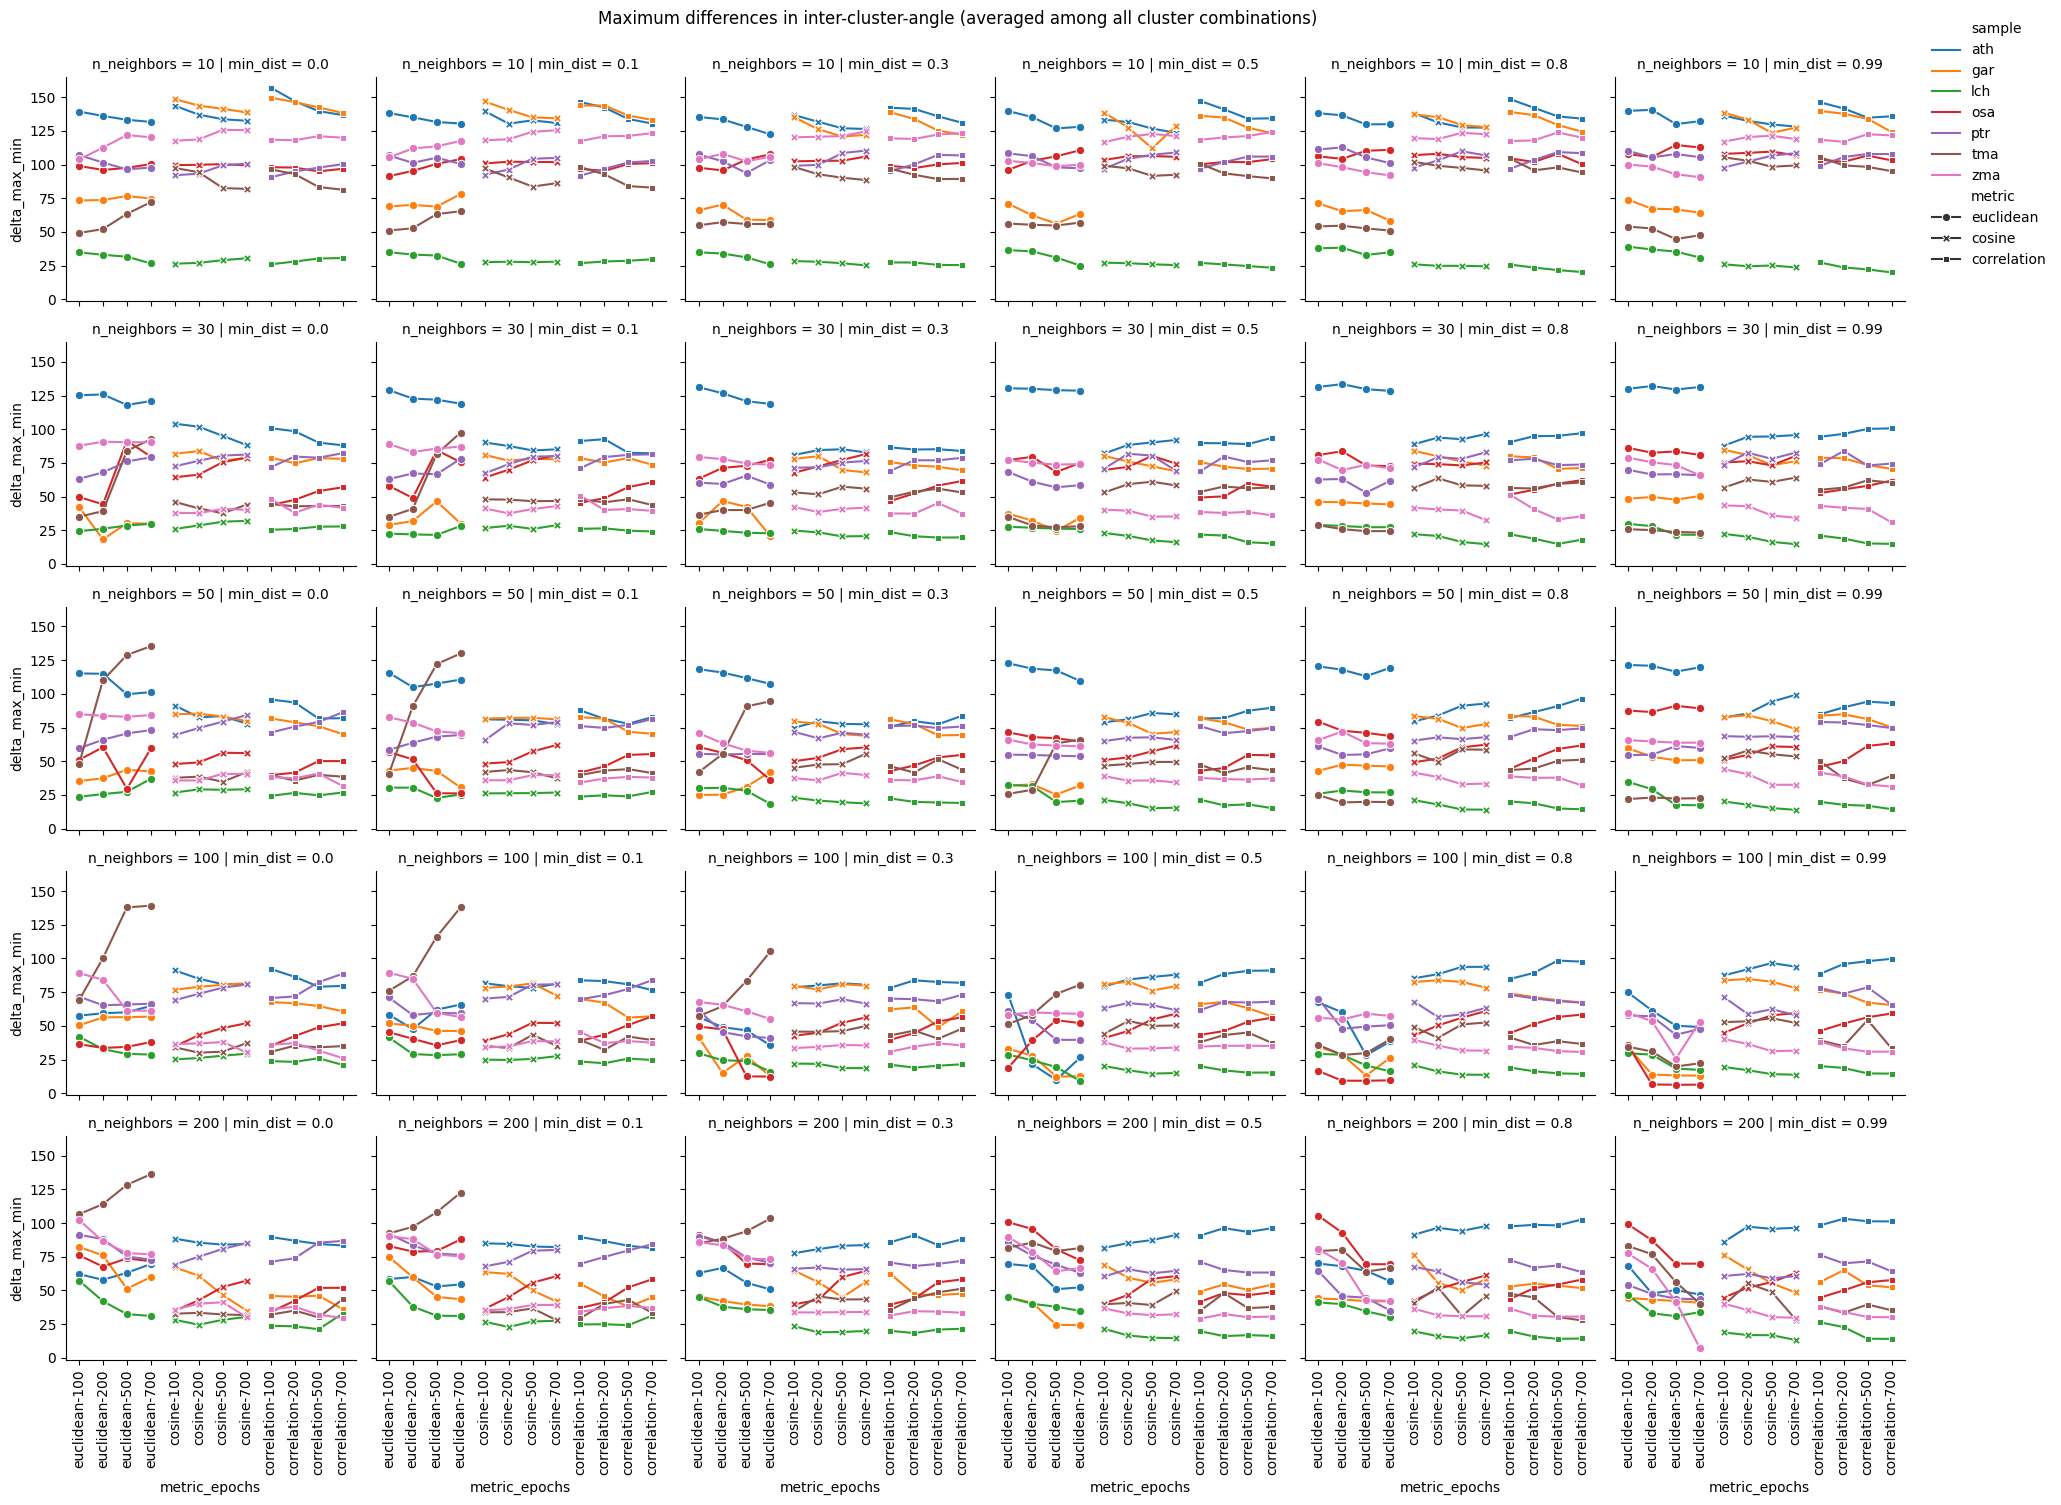

In [114]:
# data = stat_df.groupby(["n_neighbors", "min_dist", "metric", "n_epochs", "sample"]).mean().reset_index()
data = stat_df.copy()
data["metric_epochs"] = data.apply(lambda x: f"{x.metric}-{x.n_epochs}", axis=1)
g = sns.FacetGrid(
    data,
    row="n_neighbors",
    col="min_dist",
)
g.map_dataframe(
    sns.lineplot,
    x="metric_epochs",
    y="delta_max_min",
    hue="sample",
    style="metric",
    palette="tab10",
    err_style=None,
    dashes=False,
    markers=True
)
# g.map_dataframe(
#     sns.stripplot,
#     x="metric_epochs",
#     y="delta_max_min",
#     hue="sample",
#     palette="tab10",
#     dodge=.3
# )
g.tick_params(axis="x", rotation=90)
g.add_legend()
g.fig.suptitle("Maximum differences in inter-cluster-angle (averaged among all cluster combinations)", y=1.0)
sns.move_legend(g, "upper left", bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()
g.savefig(paths.outdir() / "average_max_angular_difference.svg")

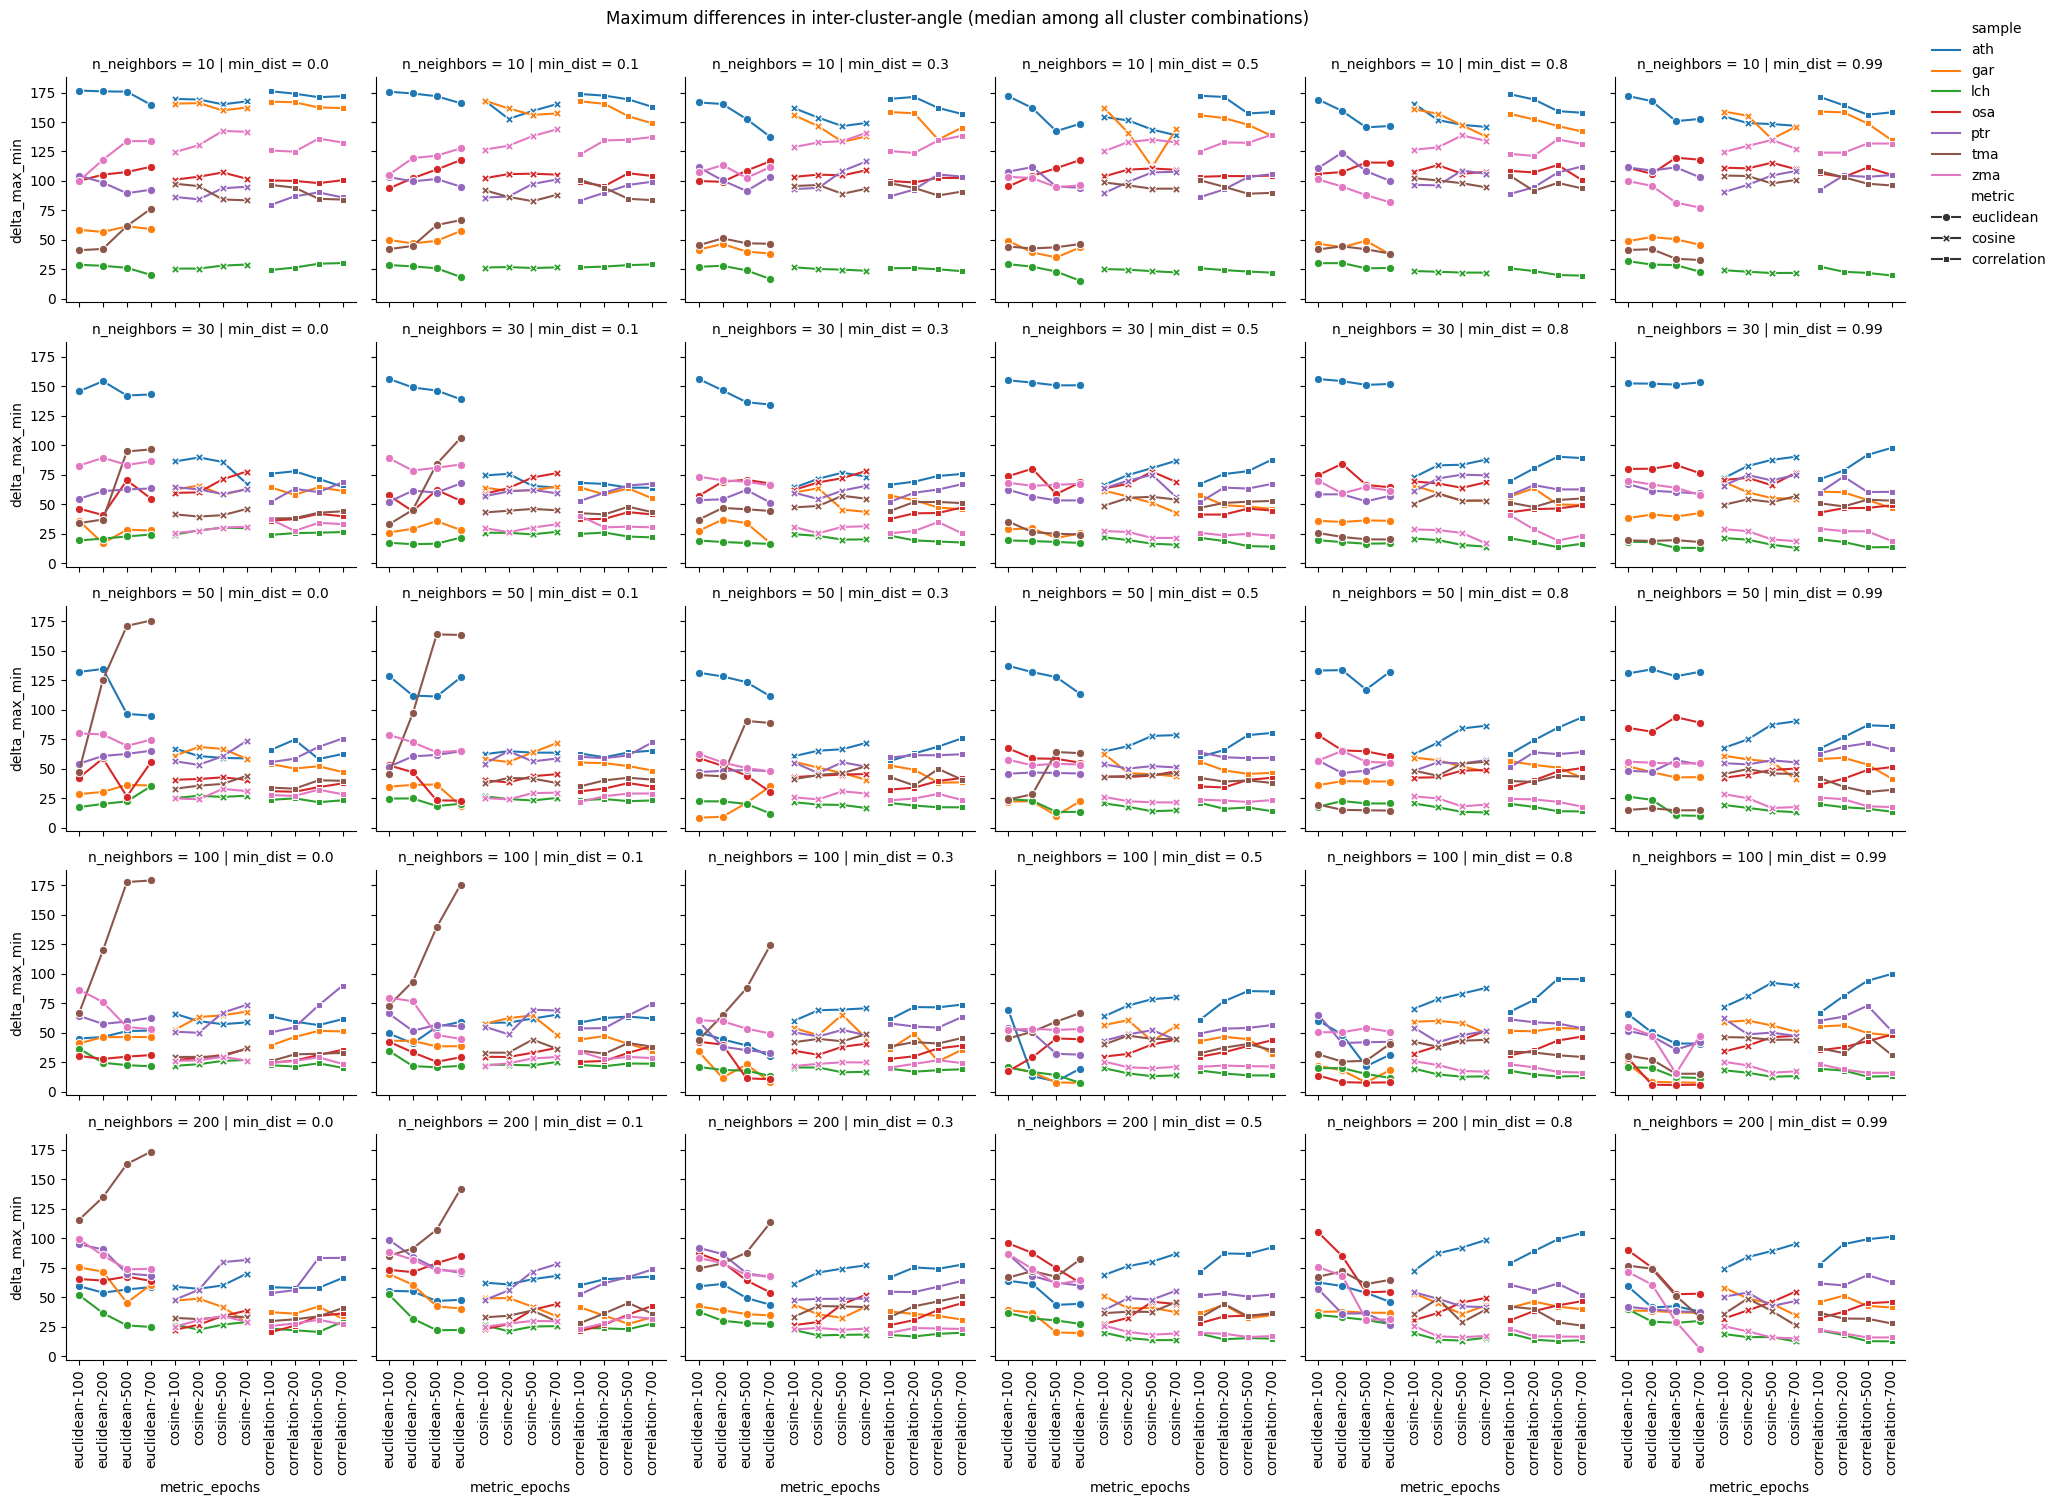

In [113]:
# data = stat_df.groupby(["n_neighbors", "min_dist", "metric", "n_epochs", "sample"]).mean().reset_index()
data = stat_df.copy()
data["metric_epochs"] = data.apply(lambda x: f"{x.metric}-{x.n_epochs}", axis=1)
g = sns.FacetGrid(
    data,
    row="n_neighbors",
    col="min_dist",
)
g.map_dataframe(
    sns.lineplot,
    x="metric_epochs",
    y="delta_max_min",
    hue="sample",
    style="metric",
    palette="tab10",
    estimator="median",
    err_style=None,
    dashes=False,
    markers=True
)
g.tick_params(axis="x", rotation=90)
g.add_legend()
g.fig.suptitle("Maximum differences in inter-cluster-angle (median among all cluster combinations)", y=1.0)
sns.move_legend(g, "upper left", bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()
g.savefig(paths.outdir() / "median_max_angular_difference.svg")

### Show extreme UMAP embeddings

Plot UMAPs where max(degree), min(degree) are observed

In [123]:
def plot_umap(path_embeddings, cluster_df, ax, highlights=None, bold=[], palette=None, **kwargs):
    # combinding embeddings with cluster_df
    embeddings = pd.read_csv(path_embeddings, index_col=0)
    embeddings_clusters = pd.merge(embeddings, cluster_df, left_index=True, right_index=True)

    # calculate cluster centroids
    cluster_centroids = embeddings_clusters.groupby(["cluster"]).median()
    cluster_centroids["cluster"] = cluster_centroids.index.tolist()

    # highlight all cluster if `hightlights` is not specified
    if highlights is None:
        highlights = embeddings_clusters["cluster"].unique().tolist()

    # assign non-highlight cluster as lightgray
    if palette is not None:
        palette = palette.copy()
        for clust in palette.keys():
            if clust not in highlights:
                palette[clust] = "lightgray"
        
    # plot cells
    sns.scatterplot(
        embeddings_clusters,
        x="UMAP1",
        y="UMAP2",
        hue="cluster",
        palette=palette,
        ax=ax,
        **kwargs
    )

    # plot cluster centorid and text lable
    for index, row in cluster_centroids.loc[highlights, :].iterrows():
        ax.text(
            x=row["UMAP1"],
            y=row["UMAP2"],
            s=row["cluster"],
            color="black",
            fontsize="large",
            fontweight="black" if row["cluster"] in bold else "normal",
            ha="center",
            va="center"
        )    
    # if highlights is not None:
    #     return palette, cluster_centroids
    #     fig = sns.scatterplot(
    #         cluster_centroids,
    #         x="UMAP1",
    #         y="UMAP2",
    #         c=[palette[c] for c in cluster_centroids["cluster"]],
    #         ax=ax,
    #         s=kwargs.get(s, 4) * 40
    #     )
    ax.relim()
    ax.autoscale_view()
    ax.set_axis_off()
    
    return

In [ ]:
max_min_umap_dir = paths.outdir() / "max_min_angle_umap"
os.makedirs(max_min_umap_dir, exist_ok=True)
for metric in param_sets["metric"].unique().tolist():
    for sample in samples:
        ica_max_min = stat_df.query("(sample == @sample) & (metric == @metric)")
    
        #
        g_max = sns.FacetGrid(ica_max_min, row="n_neighbors", col="min_dist", sharex=False, sharey=False)
        g_min = sns.FacetGrid(ica_max_min, row="n_neighbors", col="min_dist", sharex=False, sharey=False)
        
        #
        row_levels = {value: idx for idx, value in enumerate(ica_max_min["n_neighbors"].unique())}
        col_levels = {value: idx for idx, value in enumerate(ica_max_min["min_dist"].unique())}
        
        #
        labels = cluster_dfs[sample]["cluster"].unique()
        colors = plt.get_cmap("tab10").colors
        palette = {k: colors[i % len(colors)] for i, k in enumerate(labels)}
        
        #
        for nn in ica_max_min["n_neighbors"].unique():
            for md in ica_max_min["min_dist"].unique():
                # 
                row_n = row_levels[nn]
                col_n = col_levels[md]
        
                # 
                ica_diff_subset = ica_max_min.query("(n_neighbors == @nn) & (min_dist == @md) & (n_epochs == 200)").reset_index()
                ica_max_diff = ica_diff_subset.loc[ica_diff_subset["delta_max_min"].idxmax(), :]
                
                #
                path_embeddings_max = paths.embeddings(
                    sample=sample,
                    seed=ica_max_diff["max_degree_seed"],
                    param_set=ica_max_diff["param_set"]
                )
                plot_umap(
                    path_embeddings_max,
                    cluster_dfs[sample], 
                    ax=g_max.axes[row_n][col_n], 
                    highlights=ica_max_diff[["vertex", "cluster_a", "cluster_b"]].values.astype(str).tolist(),
                    bold=ica_max_diff[["vertex"]].values.astype(str).tolist(),
                    palette=palette.copy(),
                    legend=False, 
                    s=1,
                    edgecolors="none"
                )
    
                # 
                path_embeddings_min = paths.embeddings(
                    sample=sample,
                    seed=ica_max_diff["min_degree_seed"],
                    param_set=ica_max_diff["param_set"]
                )
                plot_umap(
                    path_embeddings_min, 
                    cluster_dfs[sample],
                    ax=g_min.axes[row_n][col_n], 
                    highlights=ica_max_diff[["vertex", "cluster_a", "cluster_b"]].values.astype(str).tolist(),
                    bold=ica_max_diff[["vertex"]].values.astype(str).tolist(),
                    palette=palette,
                    legend=False, 
                    s=1,
                    edgecolors="none"
                )

        # save and close
        g_max.savefig(max_min_umap_dir / f"max_angle_umap_metric={metric}_n_epochs=200_sample={sample}.png")
        g_min.savefig(max_min_umap_dir / f"min_angle_umap_metric={metric}_n_epochs=200_sample={sample}.png")
        plt.close("all")

## See if SD and Max-delta inter-cluster-angle are lower after Procrustes alignments

In [139]:
align_per_n = [10, 20, 50, 100]
temp_list = []
for sample, n, param_set in list(product(samples, align_per_n, param_sets.index.tolist())):
    foo = pd.read_csv(paths.ica_aligned(sample=sample, n=n, param_set=param_set))
    foo = foo.query("(vertex < 8) & (cluster_a < 8) & (cluster_b < 8)")
    foo["sample"] = sample
    foo["param_set"] = param_set
    foo["align_per_n"] = n
    def cos_to_degree(x):
        return np.degrees(np.arccos(x))
    foo["degree"] = foo["cos_similarity"].apply(cos_to_degree)
    foo = foo.drop(columns=["cos_similarity"])
    foo = foo.merge(param_sets, left_on="param_set", right_index=True)
    temp_list.append(foo)
    
ica_df_aligned = pd.concat(temp_list, ignore_index=True)
del temp_list

Calculate SD of inter-cluster-angle across all cluster combinations

In [145]:
stat_df_aligned = pd.DataFrame()
# TODO: start here
stat_df_aligned = ica_df_aligned.groupby(
    ["sample", "align_per_n", "param_set", "vertex", "cluster_a", "cluster_b"]
).agg(
    max_degree=("degree", "max"),
    min_degree=("degree", "min"),
    degree_sd=("degree", "std")
)
stat_df_aligned["delta_max_min"] = stat_df_aligned.apply(lambda x: abs(x["max_degree"] - x["min_degree"]), axis=1)
stat_df_aligned = pd.merge(stat_df_aligned, param_sets, left_on="param_set", right_index=True, how="left")
stat_df_aligned = stat_df_aligned.reset_index()

Plot average SD among cluster combinations  
For each sample:  
- row = n_neighbors
- col = min_dist
- hue = align_per_n
- x = metric_epochs
- y = SD


In [149]:
stat_df_aligned.head()

,sample,align_per_n,param_set,vertex,cluster_a,cluster_b,max_degree,min_degree,degree_sd,delta_max_min,n_neighbors,min_dist,metric,n_epochs
0,ath,10,0,0,1,2,31.879260,0.450568,6.350358,31.428693,10,0.0,euclidean,100
1,ath,10,0,0,1,3,19.705871,6.557135,2.469506,13.148736,10,0.0,euclidean,100
2,ath,10,0,0,1,4,19.959476,4.092576,2.712330,15.866899,10,0.0,euclidean,100
3,ath,10,0,0,1,5,16.614956,0.032004,4.119145,16.582952,10,0.0,euclidean,100
4,ath,10,0,0,1,6,37.191420,16.454337,3.488805,20.737083,10,0.0,euclidean,100


In [153]:
data = stat_df.copy()
data["align_per_n"] = 0
data[stat_df_aligned.columns]

,sample,align_per_n,param_set,vertex,cluster_a,cluster_b,max_degree,min_degree,degree_sd,delta_max_min,n_neighbors,min_dist,metric,n_epochs
0,ath,0,0,0,1,2,36.232564,0.069192,10.225038,36.163372,10,0.00,euclidean,100
1,ath,0,0,0,1,3,27.942882,0.003392,6.115227,27.939490,10,0.00,euclidean,100
2,ath,0,0,0,1,4,29.958105,0.012542,5.378503,29.945562,10,0.00,euclidean,100
3,ath,0,0,0,1,5,46.401134,0.042610,10.155650,46.358523,10,0.00,euclidean,100
4,ath,0,0,0,1,6,61.184231,2.635450,10.090987,58.548780,10,0.00,euclidean,100
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
423355,zma,0,359,7,3,5,125.553378,98.622871,6.316734,26.930507,200,0.99,correlation,700
423356,zma,0,359,7,3,6,131.947138,53.756575,28.981211,78.190563,200,0.99,correlation,700
423357,zma,0,359,7,4,5,73.067988,55.604869,3.313345,17.463119,200,0.99,correlation,700
423358,zma,0,359,7,4,6,179.998328,96.980652,31.571197,83.017676,200,0.99,correlation,700


In [ ]:
data = stat_df.copy()
data["align_per_n"] = 0
data = pd.concat([stat_df_aligned, data[stat_df_aligned.columns]])
data["metric_epochs"] = data.apply(lambda x: f"{x.metric}-{x.n_epochs}", axis=1)

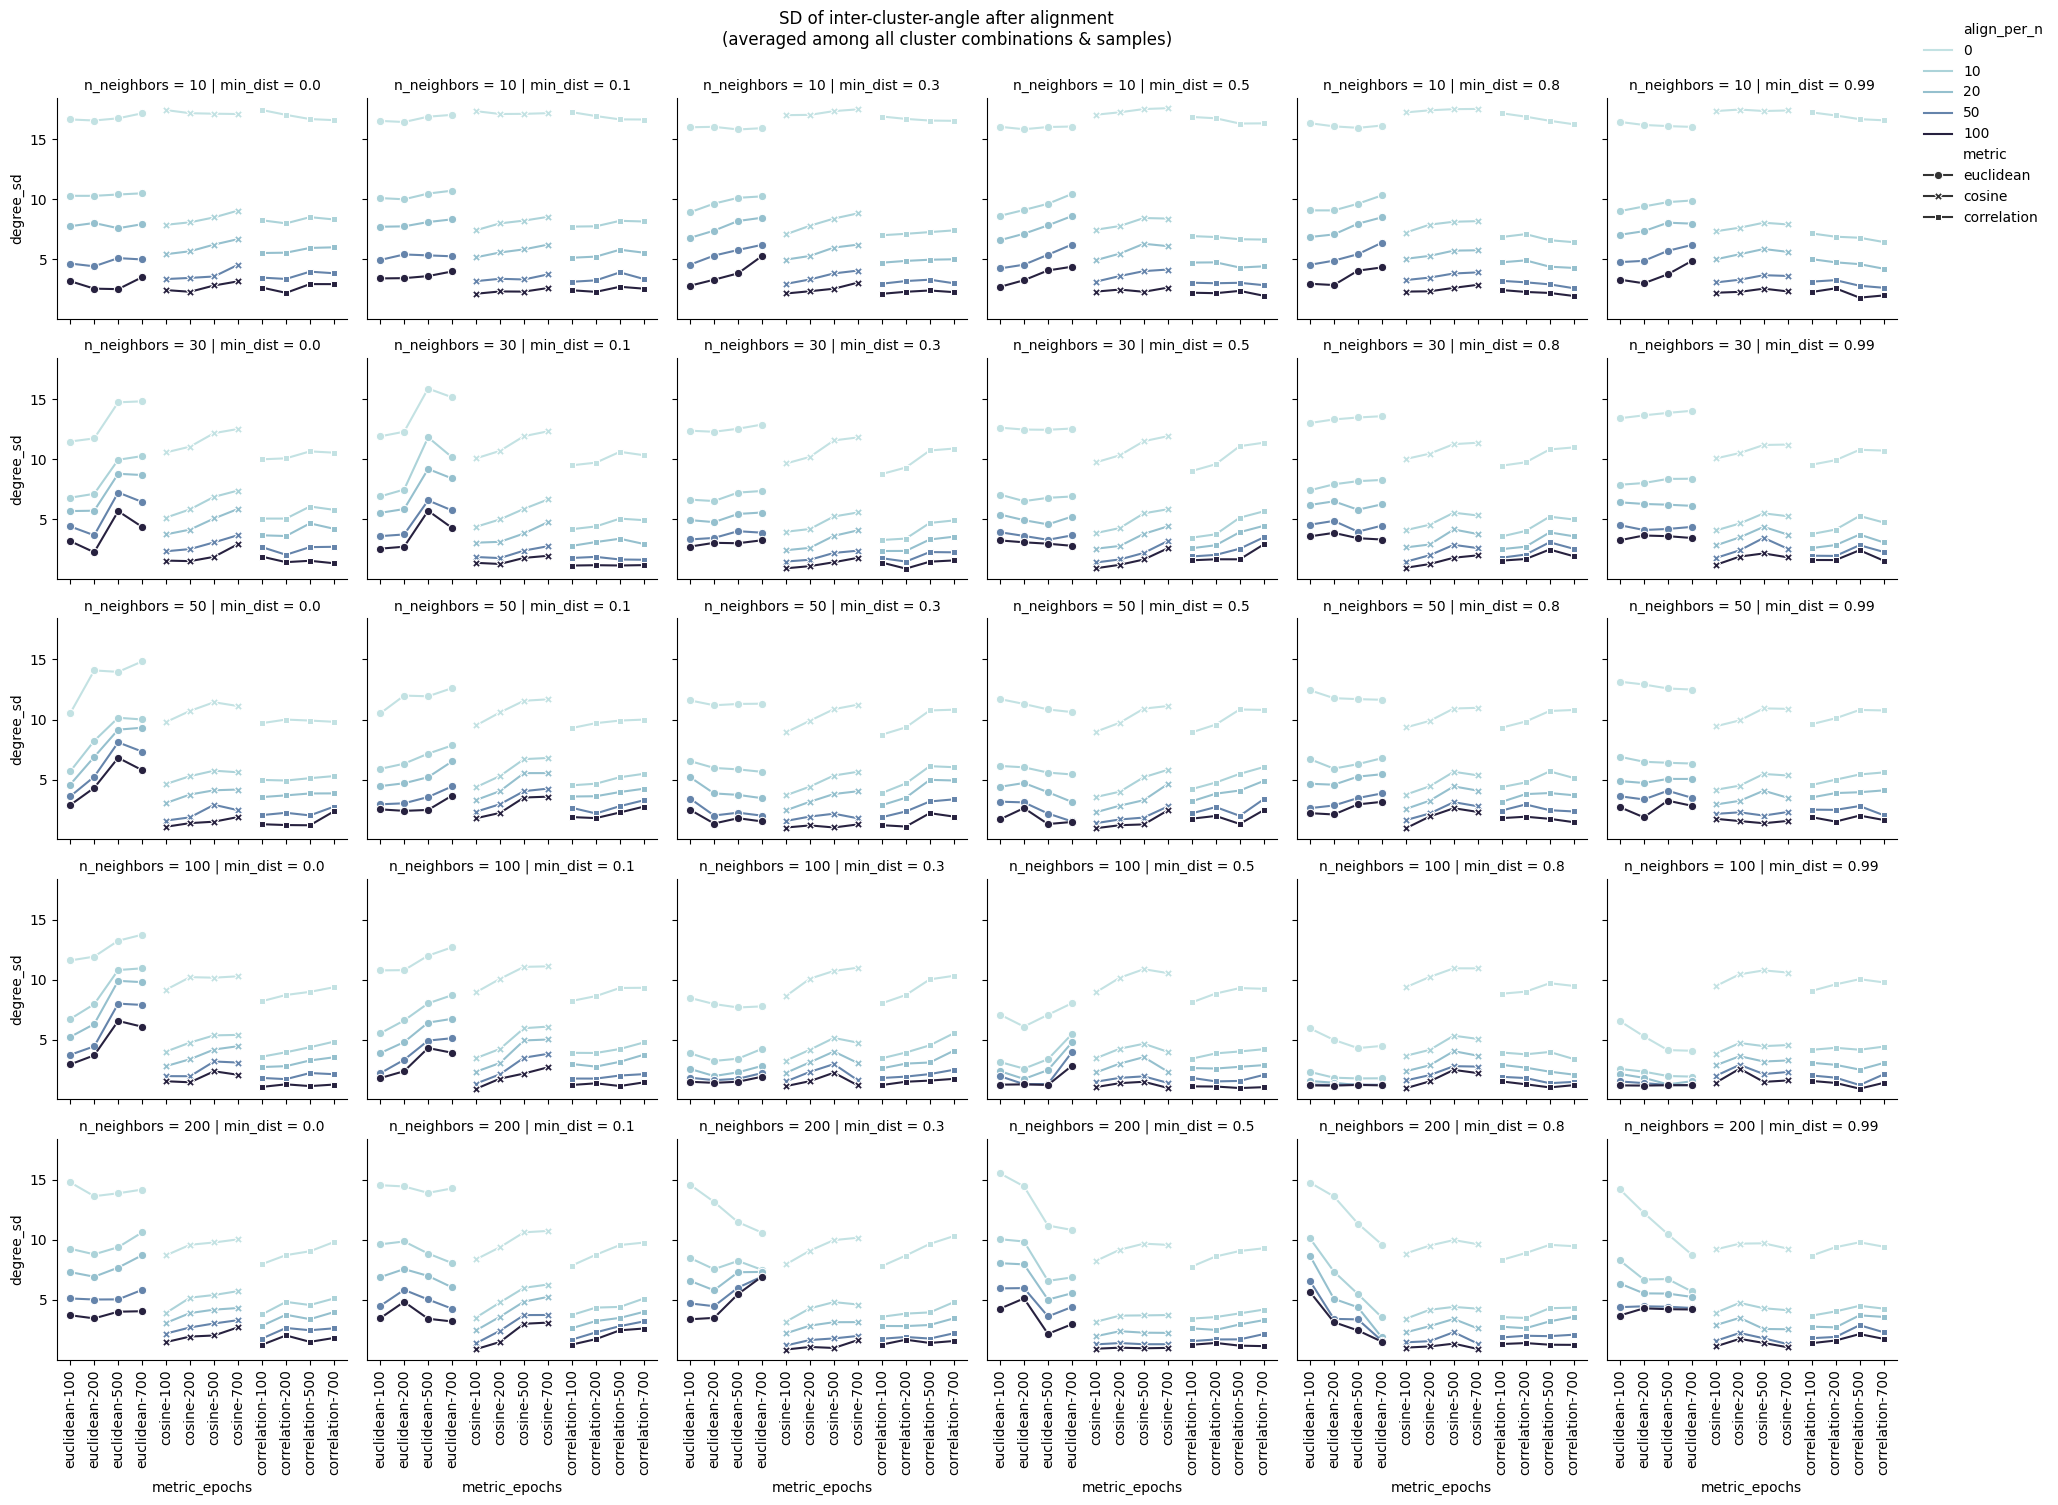

In [160]:
g = sns.FacetGrid(
    data,
    row="n_neighbors",
    col="min_dist",
)
g.map_dataframe(
    sns.lineplot,
    x="metric_epochs",
    y="degree_sd",
    hue="align_per_n",
    style="metric",
    palette="ch:start=.2,rot=-.3",
    err_style=None,
    dashes=False,
    markers=True
)
g.tick_params(axis="x", rotation=90)
g.add_legend()
g.fig.suptitle("SD of inter-cluster-angle after alignment\n(averaged among all cluster combinations & samples)", y=1.0)
sns.move_legend(g, "upper left", bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()
g.savefig(paths.outdir() / "average_angle_sd_aligned.svg")

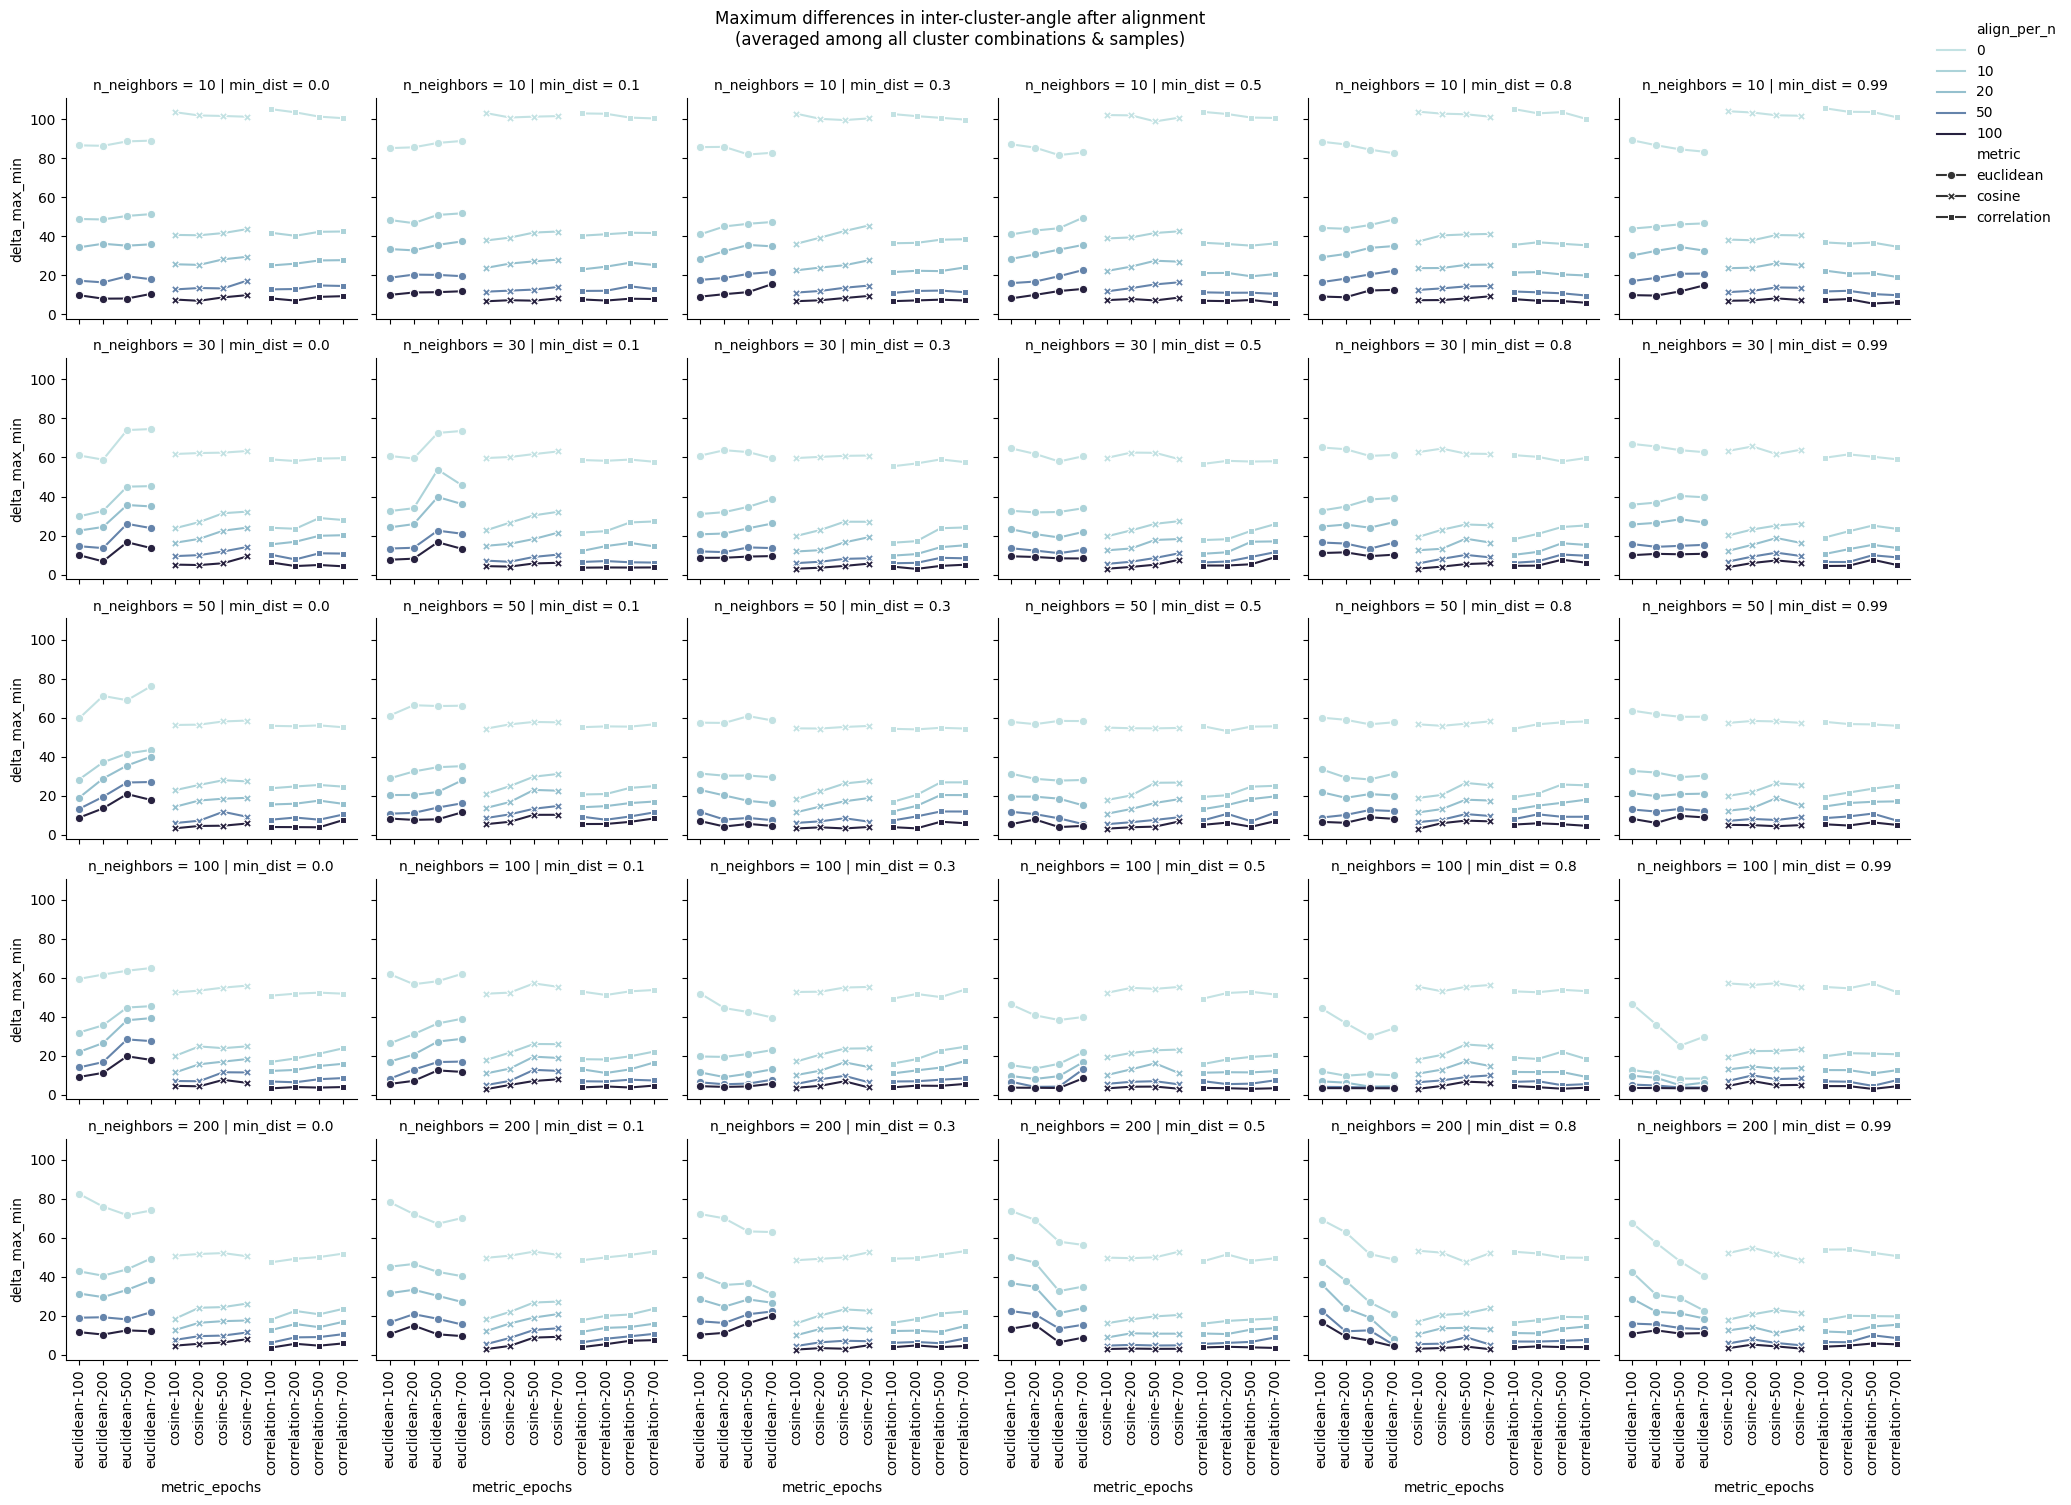

In [159]:
g = sns.FacetGrid(
    data,
    row="n_neighbors",
    col="min_dist",
)
g.map_dataframe(
    sns.lineplot,
    x="metric_epochs",
    y="delta_max_min",
    hue="align_per_n",
    style="metric",
    palette="ch:start=.2,rot=-.3",
    err_style=None,
    dashes=False,
    markers=True
)
g.tick_params(axis="x", rotation=90)
g.add_legend()
g.fig.suptitle("Maximum differences in inter-cluster-angle after alignment\n(averaged among all cluster combinations & samples)", y=1.0)
sns.move_legend(g, "upper left", bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()
g.savefig(paths.outdir() / "average_max_angular_difference_aligned.svg")